###Extractor_AGENT###

In [122]:
import operator
from typing import Annotated, TypedDict, List, Optional
from pydantic import BaseModel, Field

# 1. Define the Schema for the final JSON output
class ExtractedPaperSchema(BaseModel):
    title: str = Field(description="The title of the research paper")
    abstract_claims: str = Field(description="Primary claims and objectives found in the abstract")
    methods: str = Field(description="Details of the research methodology and framework")
    results: str = Field(description="Key findings, data analysis, and statistical results")
    conclusion: str = Field(description="Final summary, implications, and future work")

# 2. Define the Subgraph State
class ExtractorState(TypedDict):
    # Inputs
    pdf_path: str
    gold_set_text: Optional[str]  # Ground truth text for WER evaluation
    
    # Internal Processing
    raw_text: str
    cleaned_english_text: str
    
    # Outputs & Metrics
    wer_score: float
    # We use 'final_json' to store the Pydantic object for the next agent
    final_json: Optional[ExtractedPaperSchema]
    
    # Error tracking
    errors: List[str]

In [123]:
import os
from getpass import getpass

# This will create a secure text box to paste your key
os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API Key: ")

In [124]:
%pip install langchain-openai langchain-core

Note: you may need to restart the kernel to use updated packages.


In [125]:
%pip install pymupdf4llm

Note: you may need to restart the kernel to use updated packages.


In [154]:
import pymupdf4llm
import fitz  # PyMuPDF
import base64
import re
from typing import Dict, Any
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

def extract_pdf_node(state: ExtractorState) -> Dict[str, Any]:
    """
    Node 1: PDF-to-Markdown extraction with Robust Vision Fallback.
    Inputs: state["pdf_path"]
    Outputs: Updates raw_text and errors.
    """
    pdf_path = state.get("pdf_path")
    md_text = ""
    
    try:
        # 1. ATTEMPT STANDARD EXTRACTION
        try:
            md_text = pymupdf4llm.to_markdown(pdf_path)
        except Exception as e:
            # If the library itself crashes, we force md_text to empty to trigger Vision
            md_text = ""

        # 2. ROBUST CONTENT CHECK (The "Junk Filter")
        # We strip everything except letters to see if there is actual "read" content
        content_only = re.sub(r'[^a-zA-Z]', '', md_text if md_text else "")
        
        # FALLBACK TRIGGER:
        # If text is empty OR has fewer than 200 actual alphabetic characters
        if not md_text or len(content_only) < 200:
            print(f"⚠️ Low content density ({len(content_only)} chars). Routing to Vision LLM: {pdf_path}")
            
            doc = fitz.open(pdf_path)
            llm_vision = ChatOpenAI(model="gpt-4o", temperature=0)
            vision_transcriptions = []

            # Process pages (Limiting to first 10 for speed/cost)
            for page_num in range(min(len(doc), 10)):
                page = doc.load_page(page_num)
                pix = page.get_pixmap(matrix=fitz.Matrix(2, 2)) 
                img_b64 = base64.b64encode(pix.tobytes("png")).decode("utf-8")

                msg = HumanMessage(
                    content=[
                        {"type": "text", "text": "Extract all text from this research paper page verbatim. Maintain headers."},
                        {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}}
                    ]
                )
                response = llm_vision.invoke([msg])
                vision_transcriptions.append(response.content)
            
            doc.close()
            md_text = "\n\n".join(vision_transcriptions)

        # 3. FINAL VALIDATION
        if not md_text or not md_text.strip():
            return {
                "errors": ["Extraction failed: Both text and Vision routes returned empty content"],
                "raw_text": ""
            }

        return {
            "raw_text": md_text,
            "errors": []
        }
        
    except Exception as e:
        return {
            "errors": [f"Critical Node Failure: {str(e)}"],
            "raw_text": ""
        }

In [78]:
#test
test_state = {
    "pdf_path": "/Users/thanawattraipat/Documents/EIL_LLM/Test_paper/A study of English communication strategies of Thai university students..pdf" 
}

output = extract_pdf_node(test_state)

#check results
if output.get("errors"):
    print(f"Extraction Failed: {output['errors']}")
else:
    print(f"Extraction Successful!")
    print(f"Total characters extracted: {len(output['raw_text'])}")
    print(output["raw_text"][:27961])

Extraction Successful!
Total characters extracted: 93115
# **A STUDY OF ENGLISH** **COMMUNICATION** **STRATEGIES OF THAI** **UNIVERSITY STUDENTS** **Suttinee Chuanchaisit [1]** **Kanchana Prapphal [2]** **Abstract**

_Thai students appear to have problems_
_communicating in English as a second_
_language, especially students of low ability._
_This may be caused not only by the lack of_
_basic grammar and vocabulary but also by_
_deficiency in the use of appropriate_
_communication strategies. Low-ability_
_students experience difficulties in selecting_
_the most appropriate strategies for many_
_communicative contexts. This study_ _[3]_ _aims_
_to obtain empirical data on the types of_
_communication strategies that low-ability_
_students select which may affect their oral_
_communication abilities. Three hundred_
_Thai university students participated in the_
_initial part of this study, 100 of whom were_
_randomly_ _selected_ _to_ _complete_ _the_


1 Ph.D. Candidate, English as an I

In [127]:
import re
from typing import Dict, Any

def clean_and_route_node(state: Dict[str, Any]) -> Dict[str, Any]:
    text = state.get("raw_text", "")
    if not text:
        return {"errors": ["No text provided"]}

    # --- STEP 1: BIBLIOGRAPHY TRUNCATION (BEFORE SPACE NORMALIZATION) ---
    # Look for 'References' or 'อ้างอิง' on its own line (possibly with Markdown #)
    # We use \b to ensure it's the whole word and check for a preceding newline.
    stop_words = r"(References|Bibliography|Works Cited|อ้างอิง|รายการอ้างอิง)"
    
    # This regex looks for the word at the start of a line, optionally bolded or a header.
    ref_match = re.search(rf"(?m)^#*\s*\**{stop_words}\**\s*$", text)
    
    if ref_match:
        # Cut the document at the start of the 'References' line
        text = text[:ref_match.start()].strip()
        text += "\n\n[DOCUMENT_TRUNCATED_AT_REFERENCES]"

    # --- STEP 2: PAGE & BLOCK CLEANING (HEADER DELETION) ---
    pages = re.split(r'\n{3,}', text)
    cleaned_pages = []
    for i, page in enumerate(pages):
        blocks = re.split(r'\n{2,}', page.strip())
        if i == 0:
            actual_content = "\n\n".join(blocks) # Keep title on page 1
        elif len(blocks) > 1:
            actual_content = "\n\n".join(blocks[1:]) # Drop margin/header
        else:
            actual_content = blocks[0] if len(blocks[0]) > 200 else ""
        if actual_content:
            cleaned_pages.append(actual_content)

    text = "\n\n".join(cleaned_pages)

    # --- STEP 3: TABLE & NOISE CLEANING ---
    text = re.sub(r"\|.*\|.*\n\|[\s\-\|]*\|.*\n(\|.*\|.*\n)*", "[TABLE_REMOVED]\n", text)
    text = re.sub(r"\n\s*\d+\s*\n", "\n", text) # Remove page numbers
    text = re.sub(r"\s+", " ", text).strip()   # NOW normalize whitespace

    # --- STEP 4: ENGLISH-PRIORITY ROUTING ---
    english_chars = re.findall(r'[a-zA-Z0-9\s.,!?;:\'\"()\-]', text)
    total_len = len(text) if len(text) > 0 else 1
    needs_translation = (len(english_chars) / total_len) < 0.85

    return {
        "cleaned_text": text,
        "needs_translation": needs_translation,
        "errors": []
    }

In [80]:
# ทดสอบเอาผลลัพธ์จาก extract_pdf_node มาเข้ากระบวนการ Clean และ Route
if not output.get("errors"):
    # จำลอง State ที่ได้จาก Node แรก
    current_state = {
        "pdf_path": test_state["pdf_path"],
        "raw_text": output["raw_text"]
    }
    
    # รัน Clean and Route Node
    cleaned_result = clean_and_route_node(current_state)
    

    print(f" Needs Translation: {cleaned_result['needs_translation']}")
    print(f" Length Change: {len(current_state['raw_text'])} -> {len(cleaned_result['cleaned_text'])} chars")
    print(cleaned_result['cleaned_text'][:50090]) 


 Needs Translation: False
 Length Change: 93115 -> 37933 chars
# **A STUDY OF ENGLISH** **COMMUNICATION** **STRATEGIES OF THAI** **UNIVERSITY STUDENTS** **Suttinee Chuanchaisit [1]** **Kanchana Prapphal [2]** **Abstract** _Thai students appear to have problems_ _communicating in English as a second_ _language, especially students of low ability._ _This may be caused not only by the lack of_ _basic grammar and vocabulary but also by_ _deficiency in the use of appropriate_ _communication strategies. Low-ability_ _students experience difficulties in selecting_ _the most appropriate strategies for many_ _communicative contexts. This study_ _[3]_ _aims_ _to obtain empirical data on the types of_ _communication strategies that low-ability_ _students select which may affect their oral_ _communication abilities. Three hundred_ _Thai university students participated in the_ _initial part of this study, 100 of whom were_ _randomly_ _selected_ _to_ _complete_ _the_ 1 Ph.D. Candidate, English as a

In [128]:
import os
import re
from typing import Dict, Any
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

def smart_translate_node(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Node 1.3: Scalable Universal Academic Translation.
    Uses field-agnostic XML anchors and role-based constraints for 100% fidelity.
    """
    
    # 1. GATEKEEPER: Maintain original logic
    if not state.get("needs_translation", False):
        # Return the original cleaned text if no translation is flagged
        return {"cleaned_english_text": state.get("cleaned_text", ""), "errors": []}

    text_to_translate = state.get("cleaned_text", "")
    if not text_to_translate:
        return {"errors": ["No text provided for translation"]}

    # 2. CONFIGURATION
    llm = ChatOpenAI(
        model="openai/gpt-4o-mini", 
        openai_api_key=os.getenv("OPENAI_API_KEY"),
        base_url="https://openrouter.ai/api/v1",
        temperature=0 
    )
    
    # 3. FIELD-AGNOSTIC TEMPLATIZED PROMPT
    # We use XML tags to provide clear "tagging" as suggested by your supervisor.
    system_instruction = (
        "### ROLE ###\n"
        "You are a Senior Universal Academic Translator specializing in multi-disciplinary research "
        "across STEM, Social Sciences, and Humanities.\n\n"
        
        "### CONTEXT ###\n"
        "You are a critical component of an automated research extraction pipeline. Your output "
        "must be formatted for machine-readability and downstream trend analysis.\n\n"
        
        "### INSTRUCTIONS ###\n"
        "1. Translate the content provided within <source_text> into formal academic English.\n"
        "2. FIELD NEUTRALITY: Use standard technical nomenclature appropriate to the document's specific field.\n"
        "3. PARAGRAPH MAPPING: Maintain a 1:1 mapping of segments. Do not merge or split paragraphs.\n"
        "4. PRESERVE FORMAT: Retain all Markdown syntax (#, ##, **, list markers) exactly.\n\n"
        
        "### RESTRICTIONS ###\n"
        "1. NO SUMMARIZATION: Do not condense the source. Every clause must be accounted for.\n"
        "2. VERBATIM ENGLISH: If a phrase or sentence is already in English, copy it VERBATIM. Do not edit for style.\n"
        "3. NO META-DATA: Do not provide introductions, conclusions, or greetings.\n"
        "4. ONLY output the translated text inside <translated_content> tags.\n\n"
        
        "### DEMONSTRATION ###\n"
        "INPUT:\n"
        "<source_text>\n"
        "# ผลการทดลอง (Results)\n"
        "จากการวิเคราะห์เชิงปริมาณพบว่า X > Y.\n"
        "</source_text>\n"
        "OUTPUT:\n"
        "<translated_content>\n"
        "# Results\n"
        "From the quantitative analysis, it was found that X > Y.\n"
        "</translated_content>"
    )
    
    user_input_format = (
        "Translate the following segment for academic analysis.\n\n"
        "<source_text>\n"
        "{input}\n"
        "</source_text>"
    )

    prompt = ChatPromptTemplate.from_messages([
        ("system", system_instruction),
        ("human", user_input_format)
    ])

    # 4. EXECUTION
    try:
        chain = prompt | llm
        response = chain.invoke({"input": text_to_translate})
        
        # Robust XML extraction logic
        raw_output = response.content
        match = re.search(r"<translated_content>(.*?)</translated_content>", raw_output, re.DOTALL)
        
        if match:
            translated_content = match.group(1).strip()
        else:
            # Fallback cleanup if the LLM forgot tags but provided content
            translated_content = raw_output.replace("<translated_content>", "").replace("</translated_content>", "").strip()
        
        return {
            "cleaned_english_text": translated_content,
            "errors": []
        }
    except Exception as e:
        return {"errors": [f"Translation failed: {str(e)}"]}

In [82]:
# 1. Prepare the state from your previous Thai PDF extraction
# We assume 'cleaned_result' exists from your earlier cleaning test
test_input_state = {
    "needs_translation": cleaned_result.get("needs_translation", True),
    "cleaned_text": cleaned_result.get("cleaned_text", "")
}

print(f"Routing Logic: Needs Translation = {test_input_state['needs_translation']}")

# 2. Run the Smart Translate Node
# If needs_translation is False, this returns {} immediately.
# If True, it calls GPT-4o-mini.
translation_output = smart_translate_node(test_input_state)

# 3. View the Result
if translation_output.get("errors"):
    print(f"Error: {translation_output['errors']}")
elif not translation_output:
    print("Skip: Paper is already English. No translation performed.")
else:
    print("Translation Complete!")
    print("ENGLISH ACADEMIC TEXT PREVIEW:")
    print(translation_output["cleaned_english_text"][:27000])


Routing Logic: Needs Translation = False
Translation Complete!
ENGLISH ACADEMIC TEXT PREVIEW:
# **A STUDY OF ENGLISH** **COMMUNICATION** **STRATEGIES OF THAI** **UNIVERSITY STUDENTS** **Suttinee Chuanchaisit [1]** **Kanchana Prapphal [2]** **Abstract** _Thai students appear to have problems_ _communicating in English as a second_ _language, especially students of low ability._ _This may be caused not only by the lack of_ _basic grammar and vocabulary but also by_ _deficiency in the use of appropriate_ _communication strategies. Low-ability_ _students experience difficulties in selecting_ _the most appropriate strategies for many_ _communicative contexts. This study_ _[3]_ _aims_ _to obtain empirical data on the types of_ _communication strategies that low-ability_ _students select which may affect their oral_ _communication abilities. Three hundred_ _Thai university students participated in the_ _initial part of this study, 100 of whom were_ _randomly_ _selected_ _to_ _complete_ _the_ 

In [129]:
print(len(translation_output["cleaned_english_text"]))

37933


In [130]:
from langchain_openai import ChatOpenAI
from typing import Dict, Any
import os

def segment_to_json_node(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Node 1.5: Literal Semantic Segmentation.
    Segments the text 'as-is' with zero paraphrasing or summarization.
    """
    text_to_process = state.get("cleaned_english_text") or state.get("cleaned_text", "")
    
    if not text_to_process:
        return {"errors": ["No text available for segmentation"]}

    llm = ChatOpenAI(
        model="openai/gpt-4o-mini",
        openai_api_key=os.getenv("OPENAI_API_KEY"),
        base_url="https://openrouter.ai/api/v1",
        temperature=0
    )
    
    structured_llm = llm.with_structured_output(ExtractedPaperSchema)

    # IMPROVED LITERAL PROMPT
    system_prompt = (
        "### ROLE ###\n"
        "You are a Literal Document Sorter. Your job is to categorize text into specific sections without changing a single word.\n\n"
        "### OBJECTIVE ###\n"
        "Extract text from the research paper into the JSON schema provided. \n\n"
        "### STRICT CONSTRAINTS ###\n"
        "1. NO PARAPHRASING: Copy the text exactly as it appears in the source.\n"
        "2. NO SUMMARIZATION: Do not condense the content. If a section is 10 paragraphs long, the JSON field must contain all 10 paragraphs.\n"
        "3. ZERO OMISSION: Every sentence from the input must be placed into one of the following categories: title, abstract_claims, methods, results, or conclusion.\n"
        "4. AS-IS MAPPING: If a specific section header is missing, identify where that content logically begins and ends, then extract it verbatim.\n\n"
        "### FIELD DEFINITIONS ###\n"
        "- title: Literal paper title.\n"
        "- abstract_claims: The abstract and introductory goals/claims.\n"
        "- methods: The full methodology, participants, and procedure text.\n"
        "- results: All findings, data descriptions, and observations.\n"
        "- conclusion: The full discussion and pedagogical implications."
    )

    try:
        final_json_object = structured_llm.invoke([
            ("system", system_prompt),
            ("human", text_to_process)
        ])

        return {
            "final_json": final_json_object,
            "errors": []
        }
        
    except Exception as e:
        return {"errors": [f"Segmentation failed: {str(e)}"]}

In [85]:
# 1. SETUP: Gather state from your previous nodes
# We combine the results of extraction, cleaning, and translation
current_state = {
    "cleaned_text": cleaned_result.get("cleaned_text"),
    "cleaned_english_text": translation_output.get("cleaned_english_text"),
    "needs_translation": cleaned_result.get("needs_translation")
}

# 2. RUN: The Segmentation Node
print("Segmenting paper sections (verbatim)...")
segment_result = segment_to_json_node(current_state)

# 3. INSPECT: Result handling
if segment_result.get("errors"):
    print(f"Error: {segment_result['errors']}")
else:
    # final_json is an instance of ExtractedPaperSchema
    paper_data = segment_result["final_json"]
    
    print(f"TITLE: {paper_data.title}")
    
    # Check the "as-is" quality by looking at length and snippets
    sections = {
        "Abstract/Claims": paper_data.abstract_claims,
        "Methods": paper_data.methods,
        "Results": paper_data.results,
        "Conclusion": paper_data.conclusion
    }
    
    for name, content in sections.items():
        char_count = len(content)
        preview = content[:250].replace('\n', ' ')
        print(f" {name} ({char_count} chars):")
        print(f"   Snippet: {preview}...")

Segmenting paper sections (verbatim)...
TITLE: A STUDY OF ENGLISH COMMUNICATION STRATEGIES OF THAI UNIVERSITY STUDENTS
 Abstract/Claims (1322 chars):
   Snippet: Thai students appear to have problems communicating in English as a second language, especially students of low ability. This may be caused not only by the lack of basic grammar and vocabulary but also by deficiency in the use of appropriate communic...
 Methods (6706 chars):
   Snippet: The sample of population for the study consisted of 300 third-year students enrolled in the speaking course in the Faculty of Humanities of a private university in the second term of the academic year 2008. At that stage, the students had studied Eng...
 Results (15686 chars):
   Snippet: To determine the difference in types of CSs used by the two groups, the means of the self-reported scores in the SUSTI were compared. Table 1 shows the difference in the selection of the types of CSs by the two language ability groups. An independent...
 Conc

In [131]:
import json

# Check if the segmentation was successful
if not segment_result.get("errors"):
    # 1. Convert the Pydantic model to a standard Python dictionary
    paper_dict = segment_result["final_json"].model_dump()
    
    # 2. Convert dictionary to a formatted JSON string
    # ensure_ascii=False keeps any Thai/special characters readable
    json_output = json.dumps(paper_dict, indent=4, ensure_ascii=False)
    
    print("### FINAL STRUCTURED JSON RESULT ###")
    print(json_output)
else:
    print(f"Error found: {segment_result['errors']}")

### FINAL STRUCTURED JSON RESULT ###
{
    "title": "A STUDY OF ENGLISH COMMUNICATION STRATEGIES OF THAI UNIVERSITY STUDENTS",
    "abstract_claims": "Thai students appear to have problems communicating in English as a second language, especially students of low ability. This may be caused not only by the lack of basic grammar and vocabulary but also by deficiency in the use of appropriate communication strategies. Low-ability students experience difficulties in selecting the most appropriate strategies for many communicative contexts. This study aims to obtain empirical data on the types of communication strategies that low-ability students select which may affect their oral communication abilities. Three hundred Thai university students participated in the initial part of this study, 100 of whom were randomly selected to complete the 1 Ph.D. Candidate, English as an International Language (EIL) Program, Chulalongkorn University, and a Lecturer at Faculty of Humanities, University of 

In [132]:
def translation_router(state: ExtractorState):
    """
    Directs the flow based on the translation flag.
    """
    # We check if 'needs_translation' was set by the cleaning node
    if state.get("needs_translation"):
        return "translate"
    return "skip"

In [133]:
%pip install langchain-openai langchain-core langgraph

Note: you may need to restart the kernel to use updated packages.


In [134]:
from langgraph.graph import StateGraph, END

# Initialize the Subgraph
builder = StateGraph(ExtractorState)

# 1. Add your pre-defined nodes
builder.add_node("extract", extract_pdf_node)
builder.add_node("clean", clean_and_route_node)
builder.add_node("translate", smart_translate_node)
builder.add_node("segment", segment_to_json_node)

# 2. Define the Logic Flow
builder.set_entry_point("extract")

# Always clean after extraction
builder.add_edge("extract", "clean")

# Routing Logic: Translate if needed, otherwise go straight to segmenting
builder.add_conditional_edges(
    "clean",
    translation_router,
    {
        "translate": "translate",
        "skip": "segment"
    }
)

# After translation is done, it must also be segmented
builder.add_edge("translate", "segment")

# Once it's in JSON format, Agent 1 is finished
builder.add_edge("segment", END)

# 3. Compile the Subgraph
agent_1_subgraph = builder.compile()

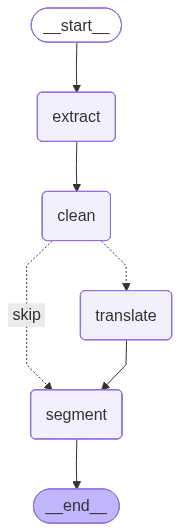

In [135]:
from IPython.display import Image, display

# 1. We use the compiled subgraph we just built
try:
    # Use mermaid.ink (an online service) to render the graph as a PNG
    display(Image(agent_1_subgraph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render diagram: {e}")
    print("Ensure you have 'pygraphviz' or an internet connection for the mermaid API.")

###KEYWORD_CANDIDATES_AGENT###

In [136]:
from pydantic import BaseModel, Field
from typing import List

class GroundedKeyword(BaseModel):
    keyword: str = Field(
        description="A distinct, high-entropy technical concept or domain-specific entity. (e.g., 'Translanguaging', 'Likert-scale')."
    )
    count: int = Field(
        description="The total number of times this specific concept or its close synonyms appear in the provided text."
    )
    evidence: str = Field(
        description="The verbatim sentence from the source text that best defines or illustrates this keyword."
    )

class KeywordCandidateSchema(BaseModel):
    candidates: List[GroundedKeyword] = Field(
        description="A list of grounded technical keyword candidates with their respective frequencies."
    )

In [137]:
import os
import re
from typing import Dict, Any
from langchain_openai import ChatOpenAI

def grounded_keyword_extractor_node(state: ExtractorState) -> Dict[str, Any]:
    """
    Node 2: Grounded Keyword Extractor.
    Extracts high-entropy entities, counts frequencies for dataviz, and 
    uses XML anchors to prevent content drift.
    """
    paper_json = state.get("final_json")
    if not paper_json:
        return {"errors": ["No segmented data found"]}

    # Input context remains consistent with your previous structure
    context_text = f"METHODS:\n{paper_json.methods}\n\nRESULTS:\n{paper_json.results}"

    llm = ChatOpenAI(
        model="openai/gpt-4o-mini",
        openai_api_key=os.getenv("OPENAI_API_KEY"),
        base_url="https://openrouter.ai/api/v1",
        temperature=0
    )
    
    # Using method="json_schema" to ensure compatibility with OpenRouter
    structured_llm = llm.with_structured_output(KeywordCandidateSchema, method="json_schema")

    # --- ENHANCED UNIVERSAL PROMPT (Role-Context-Instruction-Restriction-Demonstration) ---
    system_prompt = (
        "### ROLE ###\n"
        "You are a Universal Technical Data Miner specializing in Knowledge Graph Construction.\n\n"
        
        "### CONTEXT ###\n"
        "You are extracting core semantic entities from research text for a multi-disciplinary "
        "trend analysis dashboard. High-fidelity data is required to aggregate trends across many papers.\n\n"
        
        "### INSTRUCTIONS ###\n"
        "1. Identify 'High-Entropy' keywords: Extract specific theories, metrics, analytical frameworks, "
        "or specialized phenomena (e.g., 'Translanguaging', 'Random Forest', 'Likert-scale').\n"
        "2. FREQUENCY ANALYSIS: Scan the provided text and COUNT how many times the exact keyword or its "
        "direct synonyms appear. This is critical for data visualization weighting.\n"
        "3. GROUNDING: Provide the verbatim, unchanged sentence from the source text as evidence.\n"
        "4. FIELD AGNOSTIC: Extract based on technical density, regardless of the field (STEM, Social Science, etc.).\n\n"
        
        "### RESTRICTIONS ###\n"
        "1. NO PROCEDURAL NOISE: Do NOT extract generic words like 'analysis', 'data', 'participants', 'study', 'results'.\n"
        "2. VERBATIM ONLY: Do not paraphrase or summarize the evidence sentences.\n"
        "3. LIMIT: Identify the top 12 most defining keyword candidates.\n\n"
        
        "### DEMONSTRATION ###\n"
        "INPUT:\n"
        "<source_text>\n"
        "The study uses 'Social-Affective Strategies'. Social-Affective Strategies help students.\n"
        "</source_text>\n"
        "OUTPUT:\n"
        "keyword: 'Social-Affective Strategies', count: 2, evidence: 'The study uses Social-Affective Strategies.'\n"
    )
    
    user_input = (
        "Analyze the provided text and populate the keyword candidates schema.\n\n"
        "<source_text>\n"
        "{input}\n"
        "</source_text>"
    )

    try:
        # We wrap the context in XML tags as requested by your supervisor ("มีแท็กๆมาแปะ")
        formatted_human_input = user_input.format(input=context_text)
        
        result = structured_llm.invoke([
            ("system", system_prompt),
            ("human", formatted_human_input)
        ])
        
        return {
            "keyword_candidates": result.candidates,
            "errors": []
        }
    except Exception as e:
        return {"errors": [f"Extraction failed: {str(e)}"]}

In [93]:
import pandas as pd

# 1. จำลองผลลัพธ์
mock_state = {
    "final_json": segment_result["final_json"] 
}

# 2. รัน Node (Calling the correct function name)
extraction_result = grounded_keyword_extractor_node(mock_state)

# 3. แสดงผลเป็นตาราง
if not extraction_result.get("errors"):
    df = pd.DataFrame([
        {
            "Keyword": c.keyword, 
            "Count": c.count, 
            "Evidence (Verbatim)": c.evidence
        } 
        for c in extraction_result["keyword_candidates"]
    ])
    print("### ผลลัพธ์ Agent 2: Grounded Keyword Candidates ###")
    display(df)

### ผลลัพธ์ Agent 2: Grounded Keyword Candidates ###


,Keyword,Count,Evidence (Verbatim)
0,SUSTI,4,The main instrument used in this study was a s...
1,Likert-scale,1,A 32-item Likert-scale questionnaire was desig...
2,CSs,8,Once students had been assigned to these two g...
3,randomized block design,1,"the study’s research design, called randomized..."
4,+1 S.D.,3,The high-ability group consisted of the studen...
5,–1 S.D.,3,The high-ability group consisted of the studen...
6,independent t-test,2,An independent t-test was performed on the com...
7,risk-taking strategies,3,"As for overall risk-taking strategies, the res..."
8,risk-avoidance strategies,2,"As for the overall risk-avoidance strategies, ..."
9,help-seeking strategies,3,high-ability students’ more frequent use of th...


###GROUPER###

In [138]:
from pydantic import BaseModel, Field
from typing import List

class SemanticTopic(BaseModel):
    keywords: List[str] = Field(description="Member phrases belonging to this cluster.")
    total_count: int = Field(description="The sum of the frequencies of all member keywords in this cluster.")
    evidence: List[str] = Field(description="Supporting verbatim evidence sentences for these phrases.")
    rationale: str = Field(description="Short explanation of why these phrases refer to the same concept in this paper.")

class KeywordGrouperSchema(BaseModel):
    topics: List[SemanticTopic] = Field(description="A list of semantic clusters strictly based on provided evidence.")

In [139]:
import os
from typing import Dict, Any
from langchain_openai import ChatOpenAI

def semantic_keyword_grouper_node(state: ExtractorState) -> Dict[str, Any]:
    """
    Agent 3: Semantic Topic Clustering.
    Groups keywords by semantic equivalence and aggregates their total frequency counts.
    """
    candidates = state.get("keyword_candidates", [])
    if not candidates:
        return {"errors": ["No candidates available to group."]}

    # Prepare input: pairing keywords with their counts and evidence
    formatted_input = "\n".join([
        f"Phrase: {c.keyword} | Count: {c.count} | Evidence: {c.evidence}" 
        for c in candidates
    ])

    llm = ChatOpenAI(
        model="openai/gpt-4o-mini",
        openai_api_key=os.getenv("OPENAI_API_KEY"),
        base_url="https://openrouter.ai/api/v1",
        temperature=0
    )
    
    # Use json_schema for reliable structured output
    structured_llm = llm.with_structured_output(KeywordGrouperSchema, method="json_schema")

    # --- ENHANCED UNIVERSAL PROMPT (CO-STAR Structure) ---
    system_prompt = (
        "### ROLE ###\n"
        "You are an Information Architect specializing in Taxonomic Hierarchy and Data Aggregation.\n\n"
        
        "### CONTEXT ###\n"
        "You are consolidating raw keyword candidates into unified semantic trends. "
        "These trends will be used for a dataviz dashboard where 'total_count' determines the weight of the visual elements.\n\n"
        
        "### INSTRUCTIONS ###\n"
        "1. CLUSTERING: Group phrases ONLY if they refer to the same specific concept in this paper.\n"
        "2. FREQUENCY AGGREGATION: Calculate 'total_count' by summing the counts of all member phrases in the cluster.\n"
        "3. RATIONALE: Provide a technical explanation for the grouping based on the evidence.\n"
        "4. FIELD AGNOSTIC: Extract based on semantic equivalence regardless of the academic discipline.\n\n"
        
        "### RESTRICTIONS ###\n"
        "1. EXCLUSIVITY: A keyword phrase can only belong to ONE topic.\n"
        "2. NO NEW CONCEPTS: Do not invent names that aren't grounded in the keywords.\n"
        "3. VERBATIM EVIDENCE: Keep all evidence sentences 100% unchanged.\n\n"
        
        "### DEMONSTRATION ###\n"
        "INPUT:\n"
        "<source_text>\n"
        "Phrase: L2 Anxiety | Count: 5 | Evidence: 'L2 Anxiety affects performance.'\n"
        "Phrase: Language Anxiety | Count: 3 | Evidence: 'Language Anxiety was measured using scales.'\n"
        "</source_text>\n"
        "OUTPUT:\n"
        "Keywords: ['L2 Anxiety', 'Language Anxiety'], total_count: 8, rationale: 'Both phrases refer to the psychological state of anxiety in a language learning context.'\n"
    )

    user_input = (
        "Analyze the following keyword data and organize them into semantic topics.\n\n"
        "<source_text>\n"
        "{input}\n"
        "</source_text>"
    )

    try:
        # Wrap input in XML tags for structural grounding
        formatted_human_input = user_input.format(input=formatted_input)
        
        grouped_output = structured_llm.invoke([
            ("system", system_prompt),
            ("human", formatted_human_input)
        ])

        return {
            "semantic_topics": grouped_output.topics,
            "errors": []
        }
    except Exception as e:
        return {"errors": [f"Semantic grouping failed: {str(e)}"]}

In [96]:
# --- STEP 1: PREPARE STATE FROM AGENT 2 OUTPUT ---
# We use the candidates extracted in the previous step
test_grouper_state = {
    "keyword_candidates": extraction_result.get("keyword_candidates", [])
}

# --- STEP 2: RUN THE GROUPER ---
print("⚖️ Agent 3: Aggregating keywords and counts into semantic clusters...")
grouping_output = semantic_keyword_grouper_node(test_grouper_state)

# --- STEP 3: DISPLAY FINAL GROUPED TRENDS ---
if not grouping_output.get("errors"):
    print("\n" + "="*30 + " FINAL GROUPED TRENDS (SCALABLE) " + "="*30)
    
    # Loop through each topic to show the Rationale + Aggregated Count
    for i, topic in enumerate(grouping_output["semantic_topics"], 1):
        print(f"\n[Topic {i}] {topic.rationale.upper()}")
        print(f" 📈 Total Frequency: {topic.total_count}") # This is the key for your dataviz
        print(f" 📦 Member Phrases: {', '.join(topic.keywords)}")
        
        print(" 📄 Verbatim Evidence:")
        for ev in topic.evidence:
            print(f"   • \"{ev}\"")
else:
    print(f" Error during grouping: {grouping_output['errors']}")

⚖️ Agent 3: Aggregating keywords and counts into semantic clusters...

============================== FINAL GROUPED TRENDS (SCALABLE) ==============================

[Topic 1] THIS PHRASE REFERS SPECIFICALLY TO THE SELF-REPORT QUESTIONNAIRE USED IN THE STUDY.
 📈 Total Frequency: 4
 📦 Member Phrases: SUSTI
 📄 Verbatim Evidence:
   • "The main instrument used in this study was a self-report questionnaire, the Strategy Use in Speaking Task Inventory (SUSTI)."

[Topic 2] THIS PHRASE REFERS TO THE SPECIFIC TYPE OF QUESTIONNAIRE USED TO MEASURE STUDENT RESPONSES.
 📈 Total Frequency: 1
 📦 Member Phrases: Likert-scale
 📄 Verbatim Evidence:
   • "A 32-item Likert-scale questionnaire was designed to assess the frequency with which students used CSs in their English oral communication."

[Topic 3] THIS PHRASE REFERS TO COMMUNICATION STRATEGIES (CSS) THAT ARE BEING ANALYZED IN THE STUDY.
 📈 Total Frequency: 8
 📦 Member Phrases: CSs
 📄 Verbatim Evidence:
   • "Once students had been assigned to the

###Labeler###

In [140]:
from pydantic import BaseModel, Field
from typing import List, Optional

class TopicLabelerSchema(BaseModel):
    topic_label: str = Field(
        description="A short academic label (≤ 5 words) subsuming all keywords. Output 'LABEL_NOT_POSSIBLE' if grounding fails."
    )
    total_frequency: int = Field(
        description="The total aggregated count passed from the semantic cluster."
    )
    justification: str = Field(
        description="Technical explanation of how the label logically subsumes the keywords using text evidence."
    )

In [141]:
import os
from typing import Dict, Any
from langchain_openai import ChatOpenAI

def topic_labeler_node(state: ExtractorState) -> Dict[str, Any]:
    """
    Agent 4: Topic Labeling Agent (Subsumption Checker).
    Assigns concise, grounded academic labels and preserves aggregated frequency counts.
    """
    semantic_topics = state.get("semantic_topics", [])
    if not semantic_topics:
        return {"errors": ["No semantic clusters found to label"]}

    llm = ChatOpenAI(
        model="openai/gpt-4o-mini",
        openai_api_key=os.getenv("OPENAI_API_KEY"),
        base_url="https://openrouter.ai/api/v1",
        temperature=0
    )
    
    structured_llm = llm.with_structured_output(TopicLabelerSchema, method="json_schema")
    
    labeled_output = []

    # Process each cluster individually for high-precision naming
    for cluster in semantic_topics:
        system_prompt = (
            "### ROLE ###\n"
            "You are a Senior Taxonomic Classifier and Metadata Architect.\n\n"
            
            "### CONTEXT ###\n"
            "You are generating high-level headers for a research trend dashboard. "
            "The labels must be concise enough for a UI while remaining strictly grounded in the text.\n\n"
            
            "### INSTRUCTIONS ###\n"
            "1. Generate a concise label (≤ 5 words) that represents ALL keywords in the cluster.\n"
            "2. FIELD AGNOSTIC: Use formal academic terminology appropriate to the source field.\n"
            "3. NO SUMMARIZATION: Ensure the label is a direct logical grouping of the provided keywords.\n\n"
            
            "### RESTRICTIONS ###\n"
            "1. NO EXTERNAL KNOWLEDGE: Do not use info outside of <source_text>.\n"
            "2. VERBATIM ROOTS: The label should ideally share linguistic roots with the keywords or evidence.\n"
            "3. NO META-DATA: Output ONLY the schema content.\n\n"
            
            "### DEMONSTRATION ###\n"
            "INPUT:\n"
            "<source_text>\n"
            "Keywords: ['Social-Affective Strategies', 'Risk-Taking Techniques']\n"
            "</source_text>\n"
            "OUTPUT:\n"
            "topic_label: 'Language Communication Strategies', justification: 'Both keywords describe specific strategic approaches to L2 communication.'\n"
        )

        human_input = (
            "Assign a label to the following cluster.\n\n"
            "<source_text>\n"
            f"KEYWORDS: {cluster.keywords}\n"
            f"EVIDENCE: {cluster.evidence}\n"
            "</source_text>"
        )

        try:
            result = structured_llm.invoke([
                ("system", system_prompt),
                ("human", human_input)
            ])
            
            # Combine Agent 3 data (including count) with Agent 4 labels
            labeled_output.append({
                "label": result.topic_label,
                "total_count": cluster.total_count, # Preserving frequency for dataviz
                "justification": result.justification,
                "original_keywords": cluster.keywords,
                "evidence": cluster.evidence
            })
        except Exception as e:
            continue

    return {
        "final_labeled_topics": labeled_output,
        "errors": []
    }

In [142]:
# 1. Prepare state from Agent 3
labeler_state = {
    "semantic_topics": grouping_output.get("semantic_topics", [])
}

# 2. Run the Labeler
print("🏷️ Agent 4: Generating grounded labels and verifying frequencies...")
final_results = topic_labeler_node(labeler_state)

# 3. Display Final Results with Frequency
if not final_results.get("errors"):
    print("\n" + "★"*20 + " RESEARCH TREND DASHBOARD DATA " + "★"*20)
    for item in final_results["final_labeled_topics"]:
        print(f"\n[TOPIC LABEL]: {item['label'].upper()}")
        print(f"📊 WEIGHT (Frequency): {item['total_count']}") # Matches the variable in the node
        print(f"💡 JUSTIFICATION: {item['justification']}")
        print(f"📦 INCLUDES: {', '.join(item['original_keywords'])}")
        print("-" * 60)
else:
    print(f"Error: {final_results['errors']}")

🏷️ Agent 4: Generating grounded labels and verifying frequencies...

★★★★★★★★★★★★★★★★★★★★ RESEARCH TREND DASHBOARD DATA ★★★★★★★★★★★★★★★★★★★★

[TOPIC LABEL]: SPEAKING TASK INVENTORY
📊 WEIGHT (Frequency): 4
💡 JUSTIFICATION: The keyword 'SUSTI' refers specifically to the 'Strategy Use in Speaking Task Inventory', which is a self-report questionnaire designed for assessing strategies in speaking tasks.
📦 INCLUDES: SUSTI
------------------------------------------------------------

[TOPIC LABEL]: LIKERT-SCALE ASSESSMENT
📊 WEIGHT (Frequency): 1
💡 JUSTIFICATION: The label directly references the 'Likert-scale' keyword and encompasses its application in assessing student communication strategies.
📦 INCLUDES: Likert-scale
------------------------------------------------------------

[TOPIC LABEL]: COMMUNICATION STRATEGIES
📊 WEIGHT (Frequency): 8
💡 JUSTIFICATION: The keyword 'CSs' refers to 'Communication Strategies', which is directly evidenced by the context discussing the use of different typ

###consistency###

###stability

### COMPILE AND BATCH TEST

In [160]:
import os
import pandas as pd
import json

# 1. SETUP: Point to the Master Folder containing year subfolders
master_folder_path = "/Users/thanawattraipat/Documents/EIL_LLM/10_years_test/drive-download-20260216T090732Z-1-001 2"
final_output_list = []
paper_id_counter = 1  # Unique ID per paper (remains same for all keywords in that paper)

print(f"🚀 Starting Master Archive Processing...")

# OUTER LOOP: Iterate through each Year Subfolder (e.g., "2015", "2016", etc.)
subfolders = sorted([f for f in os.listdir(master_folder_path) if os.path.isdir(os.path.join(master_folder_path, f))])

for year_folder in subfolders:
    year_path = os.path.join(master_folder_path, year_folder)
    pdf_files = [f for f in os.listdir(year_path) if f.lower().endswith(".pdf")]
    
    print(f"\n📅 PROCESSING YEAR: {year_folder} ({len(pdf_files)} files)")
    
    # INNER LOOP: Process each PDF within that year
    for filename in pdf_files:
        full_path = os.path.join(year_path, filename)
        state = {"pdf_path": full_path, "errors": []}
        
        try:
            # --- RUN NODES (Your exact logic & variable names) ---
            state.update(extract_pdf_node(state)) # Using your updated Vision Fallback version
            state.update(clean_and_route_node(state))
            if state.get("needs_translation"):
                state.update(smart_translate_node(state))
            
            state.update(segment_to_json_node(state))
            state.update(grounded_keyword_extractor_node(state))
            state.update(semantic_keyword_grouper_node(state))
            state.update(topic_labeler_node(state))

            # --- DATA MAPPING ---
            topics = state.get("final_labeled_topics", [])
            paper = state.get("final_json")
            
            if topics and paper:
                for t in topics:
                    for kw in t.get("original_keywords", []):
                        # Fetching specific keyword data from keyword_candidates
                        kw_obj = next((c for c in state.get("keyword_candidates", []) if c.keyword == kw), None)
                        
                        final_output_list.append({
                            "paper_id": paper_id_counter, # Unique per paper
                            "year": year_folder,         # From subfolder name
                            "title": paper.title,        # From segmenter node
                            "topic": t.get("label"),     # From topic labeler node
                            "keyword": kw,
                            "keyword_frequency": kw_obj.count if kw_obj else 0,
                            "evidence": kw_obj.evidence if kw_obj else ""
                        })
                
                print(f"   ✅ {filename}: Processed (ID: {paper_id_counter})")
                paper_id_counter += 1 # Increment only after finishing all rows for this paper
            else:
                print(f"   ⚠️ {filename}: Extraction returned no data.")

        except Exception as e:
            print(f"   ❌ Error on {filename}: {str(e)}")

# 3. EXPORT
if final_output_list:
    # Export to CSV
    df_final = pd.DataFrame(final_output_list)
    csv_filename = "Master_Trends_Archive.csv"
    df_final.to_csv(csv_filename, index=False, encoding='utf-8-sig')
    
    # Export to JSON (for future computing/API use)
    json_filename = "Master_Trends_Archive.json"
    with open(json_filename, 'w', encoding='utf-8') as f:
        json.dump(final_output_list, f, ensure_ascii=False, indent=4)
        
    print(f"\n🎉 PROCESSING COMPLETE!")
    print(f"📂 Saved CSV: {csv_filename}")
    print(f"📂 Saved JSON: {json_filename}")
    display(df_final.head())
else:
    print("\n💀 No data was collected. Check your folder paths and node outputs.")

🚀 Starting Master Archive Processing...

📅 PROCESSING YEAR: 2023 (3 files)
   ✅ The Use of Peer Assessment and Non-Scripted Role-Play Activities in Improving Thai EFL High Students’ English Oral Performance..pdf: Processed (ID: 1)
   ✅ Washback of Vietnamese Standardized Test of English Proficiency (VSTEP.3-5) on Undergraduate Students’ Learning Strategies.pdf: Processed (ID: 2)
   ✅ The effects of speaking portfolios on international competence of Thai EFL undergraduate students.pdf: Processed (ID: 3)

📅 PROCESSING YEAR: 2024 (5 files)
   ✅ English plosive consonants produced by Thai speakers- An analysis of voice onset time.pdf: Processed (ID: 4)
⚠️ Low content density (0 chars). Routing to Vision LLM: /Users/thanawattraipat/Documents/EIL_LLM/10_years_test/drive-download-20260216T090732Z-1-001 2/2024/The Role of input Frequency and Different Proficiency Levels on the Perception of English Nominal Suffixes by L1 Thai Learners- A Case of the Usage-Based Account.pdf
   ⚠️ The Role of in

,paper_id,year,title,topic,keyword,keyword_frequency,evidence
0,1,2023,The Use of Peer Assessment and Non-Scripted Ro...,Mixed-Methods Research Approaches,mixed-methods,3,"This study employed a mixed-methods approach, ..."
1,1,2023,The Use of Peer Assessment and Non-Scripted Ro...,Mixed-Methods Research Approaches,quantitative,5,"This study employed a mixed-methods approach, ..."
2,1,2023,The Use of Peer Assessment and Non-Scripted Ro...,Mixed-Methods Research Approaches,qualitative,5,"This study employed a mixed-methods approach, ..."
3,1,2023,The Use of Peer Assessment and Non-Scripted Ro...,Assessment Phases,pre-test,5,"In the pre-implementation phase, the first wee..."
4,1,2023,The Use of Peer Assessment and Non-Scripted Ro...,Assessment Phases,post-test,5,A post-speaking test was administered by the s...


In [173]:
import pandas as pd
import os
import requests
import json

def classify_eil_tracks_node(input_csv: str, output_csv: str, openrouter_key: str):
    """
    Classifies papers using a direct OpenRouter API call.
    Uses your exact CO-STAR prompt and Few-Shot examples.
    """
    if not os.path.exists(input_csv):
        print(f"❌ File not found: {input_csv}")
        return
        
    df = pd.read_csv(input_csv)
    # Group by paper metadata so 1 paper = 1 row in the final output
    papers = df.groupby(['paper_id', 'year', 'title'])
    
    url = "https://openrouter.ai/api/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {openrouter_key}",
        "Content-Type": "application/json",
        "HTTP-Referer": "http://localhost:8888", # Standard OpenRouter requirement
        "X-Title": "EIL_Classifier_Node"
    }

    results = []
    print(f"🎯 Starting Direct Classification for {len(papers)} papers...")

    for (paper_id, year, title), group in papers:
        all_topics = ", ".join(group['topic'].unique().astype(str))
        all_keywords = ", ".join(group['keyword'].unique().astype(str))
        
        # --- YOUR EXACT PROMPT ---
        prompt = f"""
        # CONTEXT
        You are an expert academic registrar for the EIL Program at Chulalongkorn University (Arts, Education, and Language Institute collaboration).
        You are performing a 'Soft' Multi-Label classification of research papers based on their metadata.

        # OBJECTIVE
        Identify which of the three EIL tracks the paper belongs to. A paper can belong to MULTIPLE tracks.

        # STYLE & TONE
        Analytical, Professional, and Objective.

        # RESPONSE (Track Definitions)
        - EL (English Linguistics): Study of English structure, variation, and cultural significance.
        - ELI (English Language Instruction): Innovative teaching methodologies and diverse learning environments.
        - LAE (Language Assessment & Evaluation): Tools and frameworks to measure language proficiency.

        # FEW-SHOT EXAMPLES (Demonstrations)
        Example 1: Interdisciplinary (Teaching + Assessment)
        - Input: "The Impact of Peer Feedback on Writing Proficiency in High School Classrooms"
        - Classification: ELI: True, LAE: True, EL: False, Other: False
        Example 2: Pure Linguistics
        - Input: "A Corpus-Based Study of Lexical Bundles in Academic Abstracts"
        - Classification: EL: True, ELI: False, LAE: False, Other: False
        Example 3: Assessment Focus
        - Input: "Validating a New Rubric for Oral Presentation Assessment"
        - Classification: LAE: True, EL: False, ELI: False, Other: False

        Example 4: Fall-off / General
        - Input: "Student Housing Satisfaction and Academic Performance"
        - Classification: Other: True, EL: False, ELI: False, LAE: False

        # CURRENT DATA TO ANALYZE
        - PAPER TITLE: {title}
        - IDENTIFIED TOPICS: {all_topics}
        - EXTRACTED KEYWORDS: {all_keywords}

        # IMPORTANT: OUTPUT FORMAT
        Return ONLY a JSON object with keys "EL", "ELI", "LAE", and "Other". Use booleans (true/false).
        Do not include any conversational text.
        """

        # API Payload
        data = {
            "model": "openai/gpt-4o",
            "messages": [{"role": "user", "content": prompt}],
            "response_format": { "type": "json_object" } # Ensures strictly structured output
        }

        try:
            response = requests.post(url, headers=headers, data=json.dumps(data))
            
            if response.status_code != 200:
                print(f" ❌ Error Code {response.status_code}: {response.text}")
                continue
                
            response_json = response.json()
            content = response_json['choices'][0]['message']['content']
            res_dict = json.loads(content)
            
            # Map booleans to 1/0 for One-Hot Encoding
            results.append({
                "paper_id": paper_id,
                "year": year,
                "title": title,
                "EL": 1 if res_dict.get("EL") else 0,
                "ELI": 1 if res_dict.get("ELI") else 0,
                "LAE": 1 if res_dict.get("LAE") else 0,
                "Other": 1 if res_dict.get("Other") else 0
            })
            print(f" ✅ ID {paper_id} Mapped.")
            
        except Exception as e:
            print(f" ❌ Logic Error on ID {paper_id}: {e}")

    # Create and Save the Results
    df_one_hot = pd.DataFrame(results)
    df_one_hot.to_csv(output_csv, index=False, encoding='utf-8-sig')
    print(f"\n🎉 Process Complete! File generated: {output_csv}")
    return df_one_hot

# --- EXECUTION ---
MY_OPENROUTER_KEY = "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" # 👈 Paste your key here

classify_eil_tracks_node(
    input_csv="10years_test_1.csv", 
    output_csv="EIL_Track_OneHot_Final.csv",
    openrouter_key=MY_OPENROUTER_KEY
)

🎯 Starting Direct Classification for 48 papers...
 ✅ ID 1 Mapped.
 ✅ ID 2 Mapped.
 ✅ ID 3 Mapped.
 ✅ ID 4 Mapped.
 ✅ ID 5 Mapped.
 ✅ ID 6 Mapped.
 ✅ ID 7 Mapped.
 ✅ ID 8 Mapped.
 ✅ ID 9 Mapped.
 ✅ ID 10 Mapped.
 ✅ ID 11 Mapped.
 ✅ ID 12 Mapped.
 ✅ ID 13 Mapped.
 ✅ ID 14 Mapped.
 ✅ ID 15 Mapped.
 ✅ ID 16 Mapped.
 ✅ ID 17 Mapped.
 ✅ ID 18 Mapped.
 ✅ ID 19 Mapped.
 ✅ ID 20 Mapped.
 ✅ ID 21 Mapped.
 ✅ ID 22 Mapped.
 ✅ ID 23 Mapped.
 ✅ ID 24 Mapped.
 ✅ ID 25 Mapped.
 ✅ ID 26 Mapped.
 ✅ ID 27 Mapped.
 ✅ ID 28 Mapped.
 ✅ ID 29 Mapped.
 ✅ ID 30 Mapped.
 ✅ ID 31 Mapped.
 ✅ ID 32 Mapped.
 ✅ ID 33 Mapped.
 ✅ ID 34 Mapped.
 ✅ ID 35 Mapped.
 ✅ ID 36 Mapped.
 ✅ ID 37 Mapped.
 ✅ ID 38 Mapped.
 ✅ ID 39 Mapped.
 ✅ ID 40 Mapped.
 ✅ ID 41 Mapped.
 ✅ ID 42 Mapped.
 ✅ ID 43 Mapped.
 ✅ ID 44 Mapped.
 ✅ ID 45 Mapped.
 ✅ ID 46 Mapped.
 ✅ ID 47 Mapped.
 ✅ ID 48 Mapped.

🎉 Process Complete! File generated: EIL_Track_OneHot_Final.csv


,paper_id,year,title,EL,ELI,LAE,Other
0,1,2015,the critical reading skills of upper secondary...,0,0,1,0
1,2,2015,Implementing CLIL in Higher Education in Thail...,1,1,1,0
2,3,2015,THE EFFECTS OF COMMUNITY-BASED INSTRUCTION USI...,0,1,1,0
3,4,2015,METAPRAGMATIC AWARENESS OF THAI EFL LEARNERS,1,0,0,0
4,5,2015,Discourse connector usage in argumentative ess...,1,0,1,0
5,6,2015,Interlanguage pragmatics study of compliments ...,1,0,0,0
6,7,2015,"OJED, Vol. 11, No. 1, 2016, pp. 431 - 447 O J E D",0,1,1,0
7,8,2016,Children's Voices and Positive Affective Outco...,0,1,0,0
8,9,2016,GENDER DIFFERENCES IN PERCEIVED AND ACTUAL USE...,1,0,1,0
9,10,2016,The Effect of the Genre Awareness Approach on ...,0,1,1,0


In [175]:
import pandas as pd
import os
import requests
import json

def classify_eil_tracks_restricted(input_csv: str, output_csv: str, openrouter_key: str):
    """
    Classifies papers into exactly ONE track and outputs a One-Hot encoded CSV.
    Ensures columns are mutually exclusive (only one '1' per row).
    """
    if not os.path.exists(input_csv):
        print(f"❌ File not found: {input_csv}")
        return
        
    df = pd.read_csv(input_csv)
    papers = df.groupby(['paper_id', 'year', 'title'])
    
    url = "https://openrouter.ai/api/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {openrouter_key}",
        "Content-Type": "application/json",
        "HTTP-Referer": "http://localhost:8888",
        "X-Title": "EIL_Single_Choice_OneHot"
    }

    results = []
    print(f"🎯 Starting Single-Choice One-Hot Classification for {len(papers)} papers...")

    for (paper_id, year, title), group in papers:
        all_topics = ", ".join(group['topic'].unique().astype(str))
        all_keywords = ", ".join(group['keyword'].unique().astype(str))
        
        # --- MODIFIED CO-STAR PROMPT: FORCED SINGLE CHOICE ---
        prompt = f"""
        # CONTEXT
        You are an expert academic registrar for the EIL Program at Chulalongkorn University.
        You are classifying research papers into official tracks.

        # OBJECTIVE
        Select the SINGLE most appropriate track for the paper provided. 
        Even if the paper overlaps, you MUST choose the primary focus.

        # TRACKS
        - EL: English Linguistics (Structure, variation, linguistics).
        - ELI: English Language Instruction (Teaching, pedagogy, classroom practice).
        - LAE: Language Assessment & Evaluation (Testing, rubrics, measurement).
        - Other: General topics or those strictly outside the three above.

        # FEW-SHOT EXAMPLES
        Example 1: "Peer Feedback in Writing" -> ELI
        Example 2: "Lexical Bundles in Abstracts" -> EL
        Example 3: "Validation of Oral Rubrics" -> LAE

        # DATA
        - TITLE: {title}
        - TOPICS: {all_topics}
        - KEYWORDS: {all_keywords}

        # OUTPUT FORMAT
        Return ONLY a JSON object with the key "choice".
        The value must be exactly one of these strings: "EL", "ELI", "LAE", or "Other".
        Example: {{"choice": "ELI"}}
        """

        data = {
            "model": "openai/gpt-4o",
            "messages": [{"role": "user", "content": prompt}],
            "response_format": { "type": "json_object" }
        }

        try:
            response = requests.post(url, headers=headers, data=json.dumps(data))
            
            if response.status_code != 200:
                print(f" ❌ Error {response.status_code}: {response.text}")
                continue
                
            content = response.json()['choices'][0]['message']['content']
            res_dict = json.loads(content)
            
            # The chosen track from the LLM
            choice = res_dict.get("choice", "Other")
            
            # Map the single choice to 1-hot columns
            results.append({
                "paper_id": paper_id,
                "year": year,
                "title": title,
                "EL": 1 if choice == "EL" else 0,
                "ELI": 1 if choice == "ELI" else 0,
                "LAE": 1 if choice == "LAE" else 0,
                "Other": 1 if choice == "Other" else 0
            })
            print(f" ✅ ID {paper_id} mapped to {choice}.")
            
        except Exception as e:
            print(f" ❌ Error on ID {paper_id}: {e}")

    # Create and Save the Results
    final_df = pd.DataFrame(results)
    final_df.to_csv(output_csv, index=False, encoding='utf-8-sig')
    print(f"\n🎉 One-Hot (Single Choice) file generated: {output_csv}")
    return final_df

# --- EXECUTION ---
MY_OPENROUTER_KEY = "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"

classify_eil_tracks_restricted(
    input_csv="10years_test_1.csv", 
    output_csv="EIL_Track_10years1.csv",
    openrouter_key=MY_OPENROUTER_KEY
)

🎯 Starting Single-Choice One-Hot Classification for 48 papers...
 ✅ ID 1 mapped to LAE.
 ✅ ID 2 mapped to ELI.
 ✅ ID 3 mapped to ELI.
 ✅ ID 4 mapped to EL.
 ✅ ID 5 mapped to EL.
 ✅ ID 6 mapped to EL.
 ✅ ID 7 mapped to ELI.
 ✅ ID 8 mapped to ELI.
 ✅ ID 9 mapped to LAE.
 ✅ ID 10 mapped to ELI.
 ✅ ID 11 mapped to ELI.
 ✅ ID 12 mapped to ELI.
 ✅ ID 13 mapped to ELI.
 ✅ ID 14 mapped to ELI.
 ✅ ID 15 mapped to Other.
 ✅ ID 16 mapped to LAE.
 ✅ ID 17 mapped to ELI.
 ✅ ID 18 mapped to LAE.
 ✅ ID 19 mapped to EL.
 ✅ ID 20 mapped to ELI.
 ✅ ID 21 mapped to ELI.
 ✅ ID 22 mapped to LAE.
 ✅ ID 23 mapped to ELI.
 ✅ ID 24 mapped to EL.
 ✅ ID 25 mapped to LAE.
 ✅ ID 26 mapped to EL.
 ✅ ID 27 mapped to ELI.
 ✅ ID 28 mapped to ELI.
 ✅ ID 29 mapped to ELI.
 ✅ ID 30 mapped to ELI.
 ✅ ID 31 mapped to EL.
 ✅ ID 32 mapped to LAE.
 ✅ ID 33 mapped to EL.
 ✅ ID 34 mapped to EL.
 ✅ ID 35 mapped to ELI.
 ✅ ID 36 mapped to ELI.
 ✅ ID 37 mapped to EL.
 ✅ ID 38 mapped to EL.
 ✅ ID 39 mapped to LAE.
 ✅ ID 40 mapped t

,paper_id,year,title,EL,ELI,LAE,Other
0,1,2015,the critical reading skills of upper secondary...,0,0,1,0
1,2,2015,Implementing CLIL in Higher Education in Thail...,0,1,0,0
2,3,2015,THE EFFECTS OF COMMUNITY-BASED INSTRUCTION USI...,0,1,0,0
3,4,2015,METAPRAGMATIC AWARENESS OF THAI EFL LEARNERS,1,0,0,0
4,5,2015,Discourse connector usage in argumentative ess...,1,0,0,0
5,6,2015,Interlanguage pragmatics study of compliments ...,1,0,0,0
6,7,2015,"OJED, Vol. 11, No. 1, 2016, pp. 431 - 447 O J E D",0,1,0,0
7,8,2016,Children's Voices and Positive Affective Outco...,0,1,0,0
8,9,2016,GENDER DIFFERENCES IN PERCEIVED AND ACTUAL USE...,0,0,1,0
9,10,2016,The Effect of the Genre Awareness Approach on ...,0,1,0,0
